In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
import pickle

In [107]:
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Dataset for Isi DataScience Internship\synthetic_student_performance.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [108]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Gender             5000 non-null   int64  
 3   Ethnicity          5000 non-null   int64  
 4   ParentalEducation  5000 non-null   int64  
 5   StudyTimeWeekly    5000 non-null   int64  
 6   Absences           5000 non-null   int64  
 7   Tutoring           5000 non-null   int64  
 8   ParentalSupport    5000 non-null   int64  
 9   Extracurricular    5000 non-null   int64  
 10  Sports             5000 non-null   int64  
 11  Music              5000 non-null   int64  
 12  Volunteering       5000 non-null   int64  
 13  GPA                5000 non-null   float64
 14  GradeClass         5000 non-null   int64  
dtypes: float64(1), int64(14)
memory usage: 586.1 KB


In [110]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [111]:
encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

pickle.dump(encoders, open("encoders.pkl", "wb"))

In [112]:
# Features & target
X = df.drop(["StudentID", "GPA"], axis=1)
y = df["GPA"]


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [114]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [116]:
y_pred = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred))

Random Forest R2: 0.9440490880635527


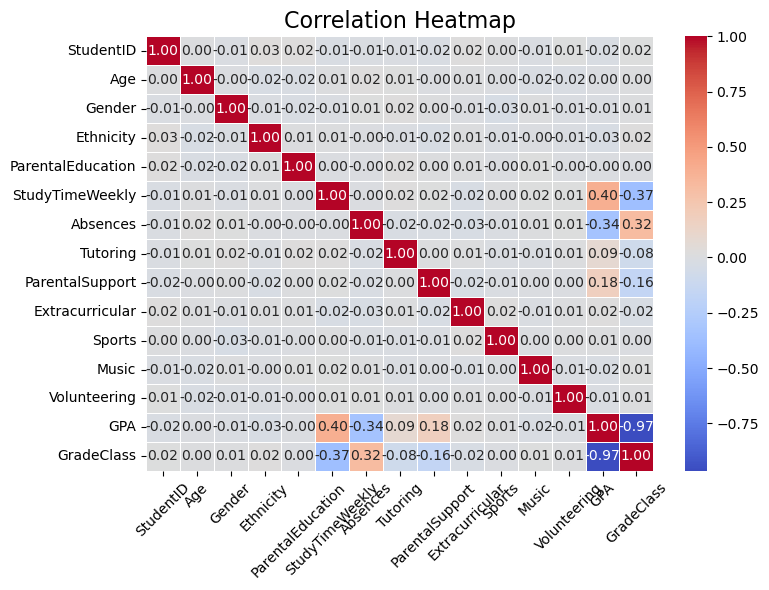

In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Dataset for Isi DataScience Internship\synthetic_student_performance.csv")  # 🔁 replace with your file

# -------------------------
# CORRELATION MATRIX
# -------------------------
corr = df.corr(numeric_only=True)

# -------------------------
# HEATMAP PLOT
# -------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,          # show values
    cmap="coolwarm",     # color style
    fmt=".2f",           # 2 decimal places
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [117]:
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
#pickle.dump(scaler, open("scaler.pkl", "wb"))

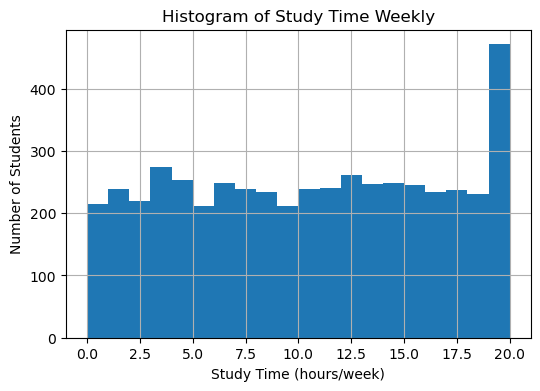

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["StudyTimeWeekly"], bins=20)
plt.title("Histogram of Study Time Weekly")
plt.xlabel("Study Time (hours/week)")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

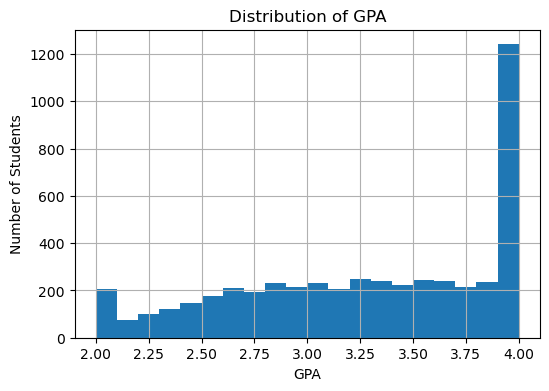

In [119]:
plt.figure(figsize=(6,4))
plt.hist(df["GPA"], bins=20)
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8092\4079150841.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = y_test.ravel() if hasattr(y_test, "ravel") else y_test


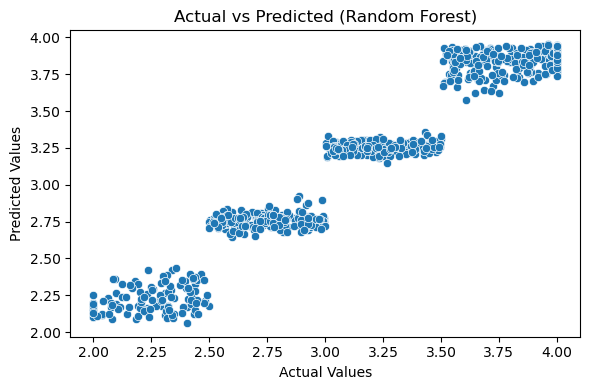

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure prediction is done
y_pred_rf = rf.predict(X_test)

# Convert to 1D if needed (avoids shape errors)
y_test = y_test.ravel() if hasattr(y_test, "ravel") else y_test
y_pred_rf = y_pred_rf.ravel()

# Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_rf)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")

plt.tight_layout()
plt.show()

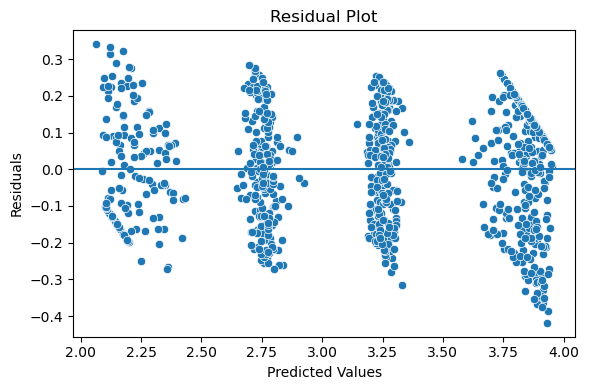

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0)  # baseline
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()